Plot successfully saved to Supplementary_Figure_S1c.pdf.


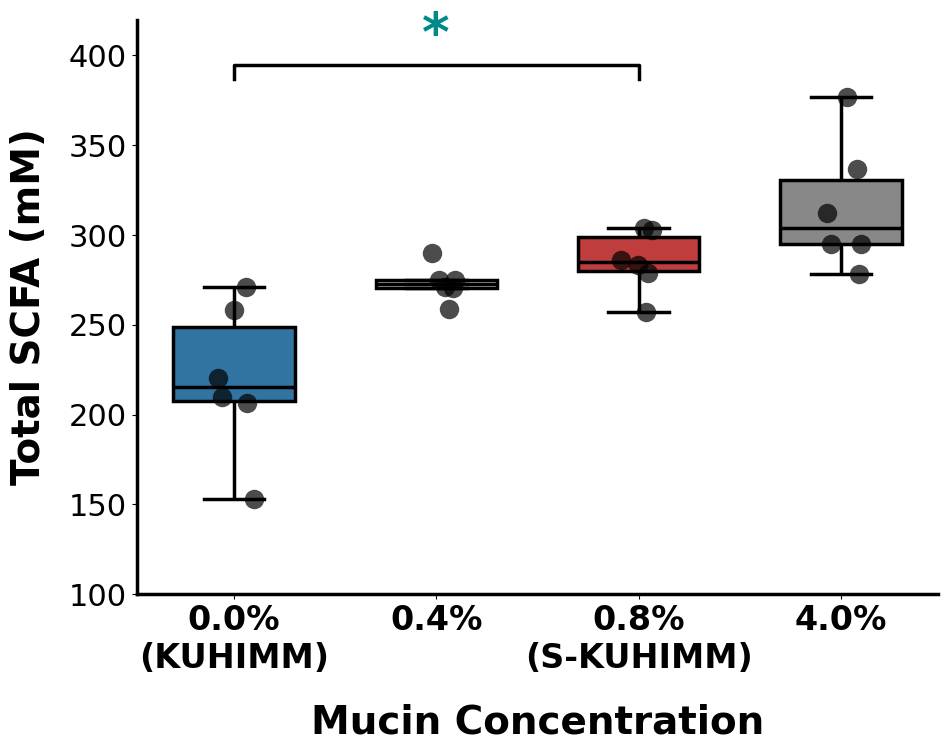

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38

# =============================================================================
# 1. Load Data & Pre-processing
# =============================================================================
df_scfa_raw = pd.read_csv("S1_Total_SCFA.csv")

# Map CSV columns to plotting labels
scfa_map = {
    'KUHIMM': '0.0% Mucin (KUHIMM)',
    '0.4% MUC': '0.4% Mucin',
    'S-KUHIMM_0.8% MUC': '0.8% Mucin (S-KUHIMM)',
    '4.0% MUC': '4.0% Mucin'
}

# Melt data into long format for Seaborn
df_scfa = df_scfa_raw.rename(columns=scfa_map).melt(id_vars=['(mM)'], var_name='Condition', value_name='SCFA')
features = ['0.0% Mucin (KUHIMM)', '0.4% Mucin', '0.8% Mucin (S-KUHIMM)', '4.0% Mucin']

# Color Palette Matching
palette = {
    '0.0% Mucin (KUHIMM)': '#1f77b4',   # Conventional Blue
    '0.4% Mucin': '#cccccc',            # Neutral Gray
    '0.8% Mucin (S-KUHIMM)': '#d62728', # Optimized Red
    '4.0% Mucin': '#888888'             # Excessive Dark Gray
}

# =============================================================================
# 2. Visualization
# =============================================================================
fig, ax_c = plt.subplots(figsize=(10, 8))

# Render Boxplots
sns.boxplot(data=df_scfa, x='Condition', y='SCFA', order=features, palette=palette,
            ax=ax_c, showfliers=False, width=0.6, linewidth=2.5, boxprops=dict(alpha=1.0))

# Enforce solid black edges
for patch in ax_c.patches: patch.set_edgecolor('black')
for line in ax_c.lines: line.set_color('black')

# Render Stripplots (Individual Donors)
sns.stripplot(data=df_scfa, x='Condition', y='SCFA', order=features,
              color='black', alpha=0.7, size=14, jitter=True, ax=ax_c)

# Aesthetics & Titles
ax_c.set_ylabel("Total SCFA (mM)", fontsize=28, fontweight='bold', labelpad=15)
ax_c.set_xlabel("Mucin Concentration", fontsize=28, fontweight='bold', labelpad=20)
ax_c.set_xticklabels(['0.0%\n(KUHIMM)', '0.4%', '0.8%\n(S-KUHIMM)', '4.0%'], fontsize=24, fontweight='bold')

# =============================================================================
# FIX: Change Y-axis limits to start from 100
# =============================================================================
y_lims = (100, 420)
ax_c.set_ylim(y_lims)
yticks = [100, 150, 200, 250, 300, 350, 400]
ax_c.set_yticks(yticks)
labels_y = ax_c.set_yticklabels([f"{t}" for t in yticks], fontsize=22)
for label in labels_y:
    label.set_fontweight('normal')

# =============================================================================
# 3. Statistical Testing (Wilcoxon Signed-Rank Test)
# =============================================================================
kuhimm_vals = df_scfa_raw['KUHIMM'].values
skuhimm_vals = df_scfa_raw['S-KUHIMM_0.8% MUC'].values
_, p_val = wilcoxon(kuhimm_vals, skuhimm_vals)

# Add Bracket and Turquoise Asterisk if significant
if p_val < 0.05:
    y_base = df_scfa['SCFA'].max() + 10 # Place slightly above the highest data point
    h = 8

    # Bracket
    ax_c.plot([0, 0, 2, 2], [y_base, y_base+h, y_base+h, y_base], lw=2.5, c='k')
    # Asterisk
    ax_c.text(1, y_base+h + h*0.2, '*', ha='center', va='bottom',
              color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

sns.despine()
plt.tight_layout()

# Export High-Resolution PDF
output_file = "Supplementary_Figure_S1c.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")